# Reproducing the main BBBC021 figures from features

This tutorial starts from the released **CellProfiler**, **DeepProfiler** and **MorphAgent** feature tables and rebuilds the two headline BBBC021 panels in the MorphAgent / BPAgent manuscript:

1. **Minimum non-redundant feature count** (within-space Pearson $|r| > 0.9$).
2. **Four-task benchmark** on CellProfiler, pretrained DeepProfiler, DeepProfiler retrained on BBBC021, and MorphAgent: perturbation detection, mechanism-of-action (MoA) prediction, same-MoA matching, and L1000 gene-expression regression. Significance marks follow the manuscript figure (non-significant comparisons are omitted).

MorphAgent uses the **467** named features in Supplementary Feature List 1 (`assets/morphagent_467_feature_names.csv`). Helper functions live in `bbbc021_main_results.py`.

**Dataset.** BBBC021 Cell Painting profiles of MCF-7 cells: **3,552** images, **37** compounds, **26** MoA labels, three channels (DAPI, tubulin, actin).


## 0. Setup

Run this notebook from `tutorial_BBBC021/`. Feature CSVs stay in `results_BBBC021_evaluation` (they are large and are not copied here). Set `RECOMPUTE = True` only if you want to ignore cached outputs.


In [1]:
from pathlib import Path
import sys

import pandas as pd
from IPython.display import Image, display

TUTORIAL = Path.cwd()
if not (TUTORIAL / "bbbc021_main_results.py").exists():
    TUTORIAL = Path("/data3/yez/MorphAgent/tutorial_BBBC021")
sys.path.insert(0, str(TUTORIAL))

import importlib
import bbbc021_main_results as bb
bb = importlib.reload(bb)

RECOMPUTE = False

bb.OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("Tutorial dir :", TUTORIAL)
print("Eval root    :", bb.EVAL_ROOT)
print("Output dir   :", bb.OUTPUT_DIR)


Tutorial dir : /data3/yez/MorphAgent/tutorial_BBBC021
Eval root    : /data3/yez/MorphAgent/results_BBBC021_evaluation
Output dir   : /data3/yez/MorphAgent/tutorial_BBBC021/outputs


## 1. Load the feature spaces

| Method | What the columns are | Width |
|--------|----------------------|-------|
| CellProfiler | handcrafted Cell Painting descriptors | 6,278 (6,256 variable) |
| DeepProfiler | pretrained embedding dimensions | 672 |
| DeepProfiler (retrained on BBBC021) | embedding trained on this dataset | 672 |
| MorphAgent | biologically named measurements (Supplementary Feature List 1) | **467** |


In [2]:
names_467 = bb.load_morphagent_467_names()
print(f"MorphAgent named vocabulary: {len(names_467)} features")
print("First 15 names:")
for i, n in enumerate(names_467[:15], 1):
    print(f"  {i:3d}. {n}")

ma467 = bb.load_morphagent_467()
print("\nMorphAgent 467-feature matrix:", ma467.shape)
print("Compounds:", ma467["perturbation_id"].nunique())
print(ma467[["sample_id", "perturbation_id"]].head())


MorphAgent named vocabulary: 467 features
First 15 names:
    1. tubulin_intensity_total
    2. actin_fiber_alignment_index
    3. cell_roundness_mean
    4. dapi_texture_entropy
    5. tubulin_actin_overlap_fraction
    6. cell_confluence_ratio
    7. dapi_intensity_std
    8. actin_radial_distribution
    9. tubulin_texture_contrast
   10. cytoplasm_nucleus_area_ratio
   11. nucleus_area_mean
   12. dapi_texture_haralick_contrast_mean
   13. micronuclei_count_mean
   14. tubulin_intensity_skewness_mean
   15. tubulin_fiber_alignment_index

MorphAgent 467-feature matrix: (3552, 469)
Compounds: 37
              sample_id perturbation_id
0  10064_alsterpaullone  alsterpaullone
1  10065_alsterpaullone  alsterpaullone
2  10066_alsterpaullone  alsterpaullone
3  10067_alsterpaullone  alsterpaullone
4  10068_alsterpaullone  alsterpaullone


In [3]:
datasets = bb.load_benchmark_tables(morphagent_source="467")
feat_cols = {k: bb.get_feature_columns(v) for k, v in datasets.items()}
inventory = pd.DataFrame([
    {
        "method": bb.method_label(k),
        "n_images": len(v),
        "n_compounds": v["perturbation_id"].nunique(),
        "n_features": len(feat_cols[k]),
    }
    for k, v in datasets.items()
])
display(inventory)
assert inventory.loc[inventory["method"] == "MorphAgent", "n_features"].item() == 467

moa = bb.load_drug_moa_map()
print(f"MoA map: {len(moa)} compounds, {len(set(str(x) for x in moa.values()))} distinct MoA labels")


Loading CellProfiler evaluation table ...
Loading DeepProfiler evaluation table (pretrained) ...
Loading DeepProfiler evaluation table (retrained on BBBC021) ...
Loading MorphAgent 467-feature vocabulary ...


,method,n_images,n_compounds,n_features
0,CellProfiler,3552,37,6278
1,DeepProfiler,3552,37,672
2,DeepProfiler (retrained on BBBC021),3552,37,672
3,MorphAgent,3552,37,467


MoA map: 37 compounds, 26 distinct MoA labels


## 2. Non-redundant feature count

A feature is called **redundant** if it has Pearson $|r| > 0.9$ with an earlier column (greedy left-to-right filter, constants dropped first). The bar height is the size of the remaining subset.

This is computed on the feature-space tables used in the manuscript panel:

- CellProfiler: `features_dataset/cellprofiler/` (includes DMSO; 3,652 rows)
- DeepProfiler: `features_dataset/deepprofiler_new/`
- MorphAgent: `features_dataset/morphagent_filtered_new/` restricted to the **467** retained names

Manuscript lock-in: **1,284 / 440 / 291**.


Loading cached non-redundant counts: /data3/yez/MorphAgent/tutorial_BBBC021/outputs/redundancy_min_subset.csv


,n_total,n_var,n_const_dropped,n_redundant_dropped,n_min_subset,n_rows
CellProfiler,6278,6256,22,4972,1284,3652
DeepProfiler,672,672,0,232,440,3552
MorphAgent,467,467,0,176,291,3552


Saved /data3/yez/MorphAgent/tutorial_BBBC021/outputs/min_nonredundant_subset.png/.svg/.pdf


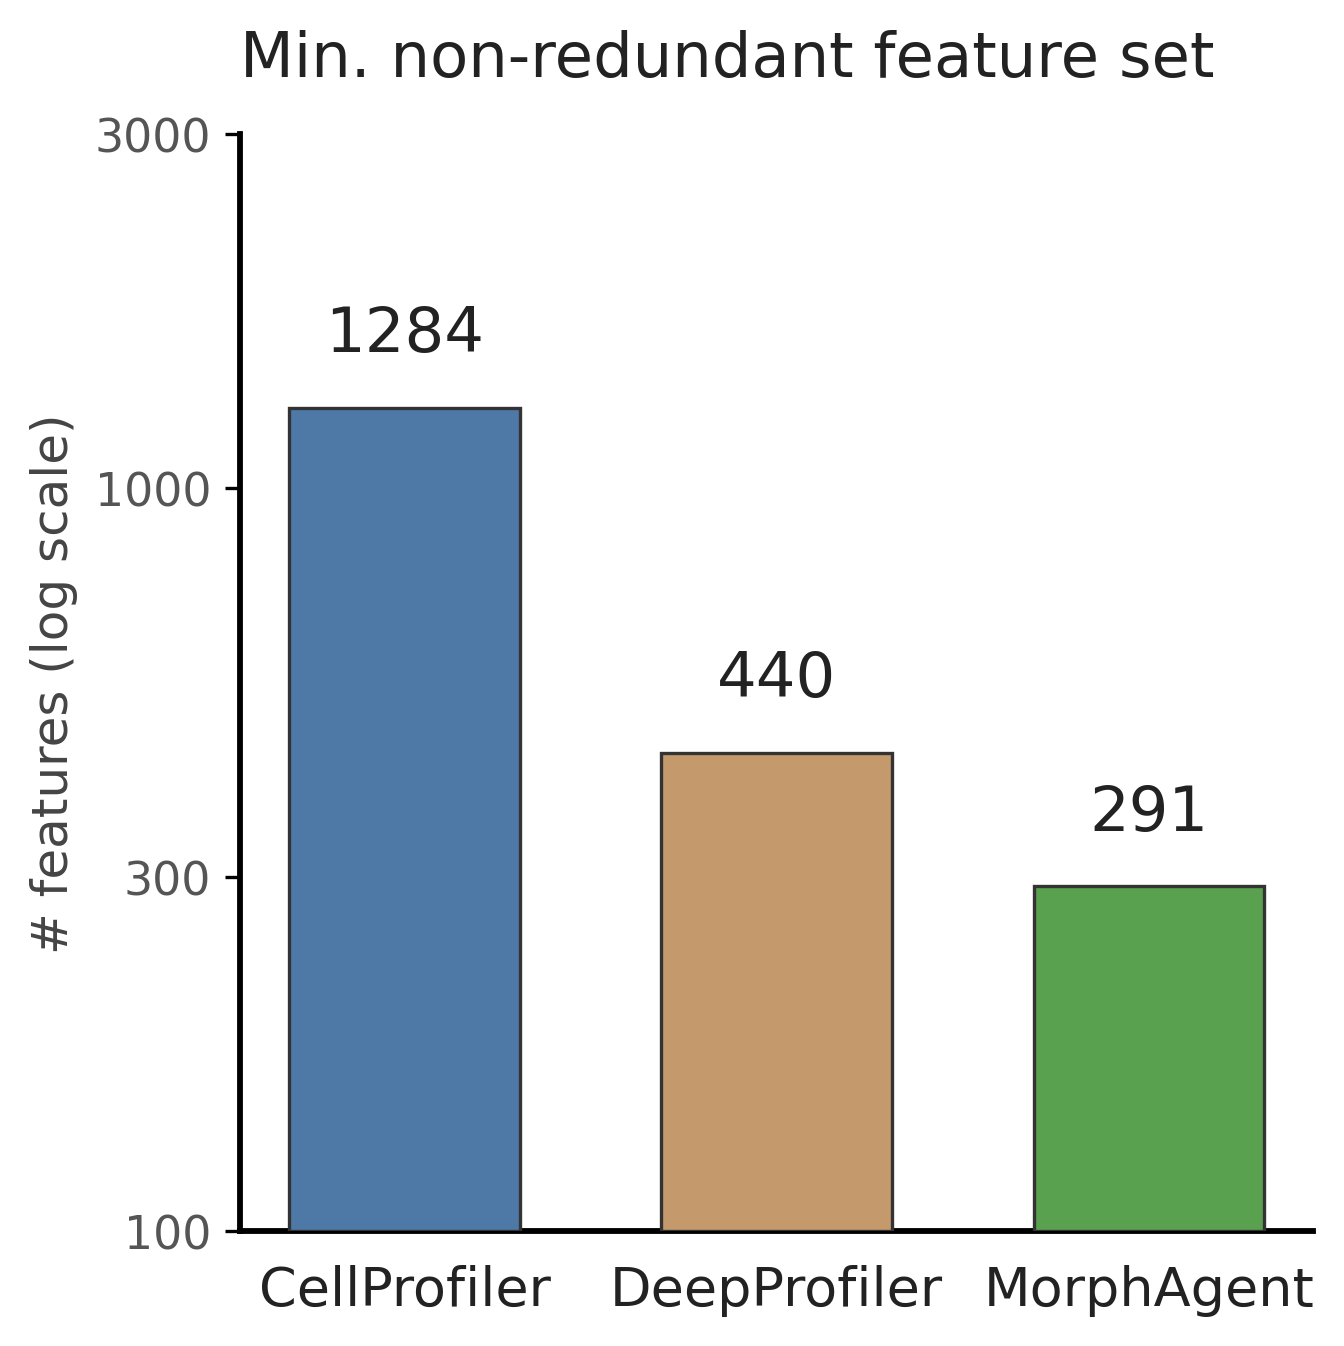


Manuscript targets: {'CellProfiler': 1284, 'DeepProfiler': 440, 'MorphAgent': 291}
  CellProfiler   reproduced=1284  manuscript=1284  delta=+0
  DeepProfiler   reproduced= 440  manuscript= 440  delta=+0
  MorphAgent     reproduced= 291  manuscript= 291  delta=+0


In [4]:
counts = bb.compute_nonredundant_counts(recompute=RECOMPUTE)
display(counts)
png = bb.plot_nonredundant(counts)
display(Image(filename=str(png)))

print("\nManuscript targets:", bb.PAPER_NONREDUNDANT)
for method, target in bb.PAPER_NONREDUNDANT.items():
    got = int(counts.loc[method, "n_min_subset"])
    print(f"  {method:13s}  reproduced={got:4d}  manuscript={target:4d}  delta={got - target:+d}")


## 3. Four-task benchmark protocol

Shared preprocessing for every method and task: keep numeric feature columns, impute non-finite values, then z-score.

All four representations are evaluated on the same 3,552 images. Uncertainty is a percentile 95% CI from **2,000** bootstrap resamples of the evaluation units. The four-panel figure copies the manuscript significance brackets and omits non-significant (`ns`) comparisons.


### 3a. Perturbation detection (image-level mAP)

Each image is a query. Rank all other images by cosine similarity; average precision is computed for retrieving the same compound, then averaged over 3,552 queries.


### 3b. MoA prediction (kNN accuracy)

Image-level 80/10/10 stratified split. Euclidean kNN with neighbourhood size chosen on validation accuracy from $\{1,3,5,7,9,11,15,21,31\}$. Reported metric: top-1 test accuracy. This is **not** a compound-holdout split.


### 3c. Same-MoA perturbation matching

Restricted to MoA groups with at least two compounds. For every ordered pair of distinct compounds that share an MoA, sample five negatives from other MoAs (six-way retrieval). Each compound is represented by its mean profile. AP reduces to $1/\mathrm{rank}$ of the positive centroid. Random baseline $\approx 0.408$.


### 3d. L1000 gene-expression regression

A two-layer MLP (512–256, dropout 0.3) maps morphology to paired L1000 profiles under a **random** sample split (seed 42). The manuscript bars freeze the released run:

| Method | R² | 95% CI |
|--------|----|--------|
| CellProfiler | 0.096 | 0.059 – 0.129 |
| DeepProfiler | 0.159 | 0.122 – 0.192 |
| DeepProfiler (retrained on BBBC021) | −0.005 | −0.019 – 0.002 |
| MorphAgent | 0.177 | 0.143 – 0.207 |

Retraining is stochastic and is **not** repeated in this tutorial; we load those published point estimates and bootstrap CIs, which is the same procedure used by the original figure scripts.


In [5]:
results = bb.run_four_benchmarks(
    datasets,
    recompute=RECOMPUTE,
    cache_tag="467",
)

print("=== Reproduced metrics ===")
for task_key, title in [
    ("perturbation_detection", "Perturbation detection"),
    ("moa_detection", "MoA prediction"),
    ("same_moa_matching", "Same-MoA matching"),
    ("l1000_regression", "L1000 regression"),
]:
    task = results[task_key]
    print(f"\n{title}")
    for m in bb.METHODS_ORDER:
        r = task["methods"][m]
        print(
            f"  {bb.method_label(m):40s}  "
            f"{r['metric_name']}={r['metric']:.4f}  "
            f"CI95=[{r['ci95'][0]:.4f}, {r['ci95'][1]:.4f}]"
        )


Loading cached benchmark results: /data3/yez/MorphAgent/tutorial_BBBC021/outputs/four_benchmark_results_467_4method.json
=== Reproduced metrics ===

Perturbation detection
  CellProfiler                              mAP=0.1544  CI95=[0.1497, 0.1593]
  DeepProfiler                              mAP=0.1902  CI95=[0.1853, 0.1951]
  DeepProfiler (retrained on BBBC021)       mAP=0.0423  CI95=[0.0416, 0.0429]
  MorphAgent                                mAP=0.2261  CI95=[0.2196, 0.2324]

MoA prediction
  CellProfiler                              Accuracy=0.4719  CI95=[0.4185, 0.5281]
  DeepProfiler                              Accuracy=0.5787  CI95=[0.5281, 0.6292]
  DeepProfiler (retrained on BBBC021)       Accuracy=0.1657  CI95=[0.1292, 0.2051]
  MorphAgent                                Accuracy=0.6433  CI95=[0.5927, 0.6938]

Same-MoA matching
  CellProfiler                              mAP=0.5244  CI95=[0.4564, 0.5971]
  DeepProfiler                              mAP=0.5428  CI95=[0.4728, 0

## 4. Four-panel figure


Saved /data3/yez/MorphAgent/tutorial_BBBC021/outputs/four_benchmarks.png/.svg/.pdf


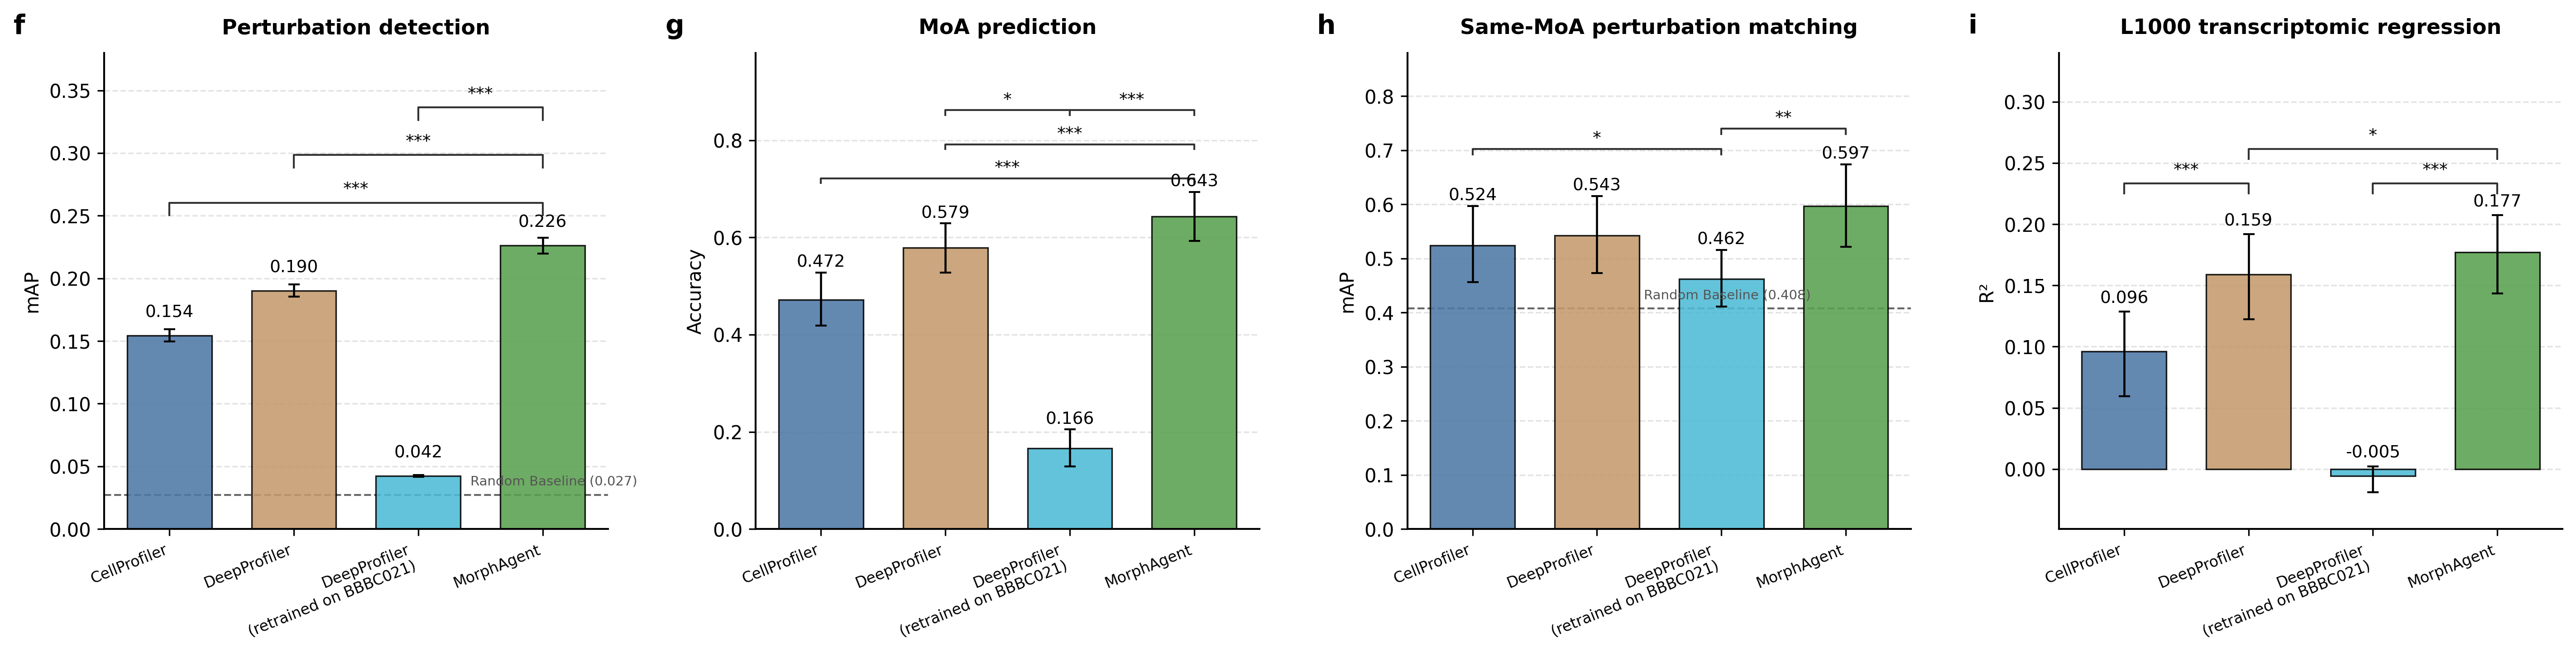

,task,method,reproduced,manuscript,abs_diff,match_3dp
0,perturbation_detection,CellProfiler,0.1544,0.154,0.000376,True
1,perturbation_detection,DeepProfiler,0.1902,0.190,0.000178,True
2,perturbation_detection,DeepProfiler (retrained on BBBC021),0.0423,0.042,0.000286,True
3,perturbation_detection,MorphAgent,0.2261,0.228,0.001887,True
4,moa_detection,CellProfiler,0.4719,0.472,0.000090,True
5,moa_detection,DeepProfiler,0.5787,0.579,0.000348,True
6,moa_detection,DeepProfiler (retrained on BBBC021),0.1657,0.166,0.000270,True
7,moa_detection,MorphAgent,0.6433,0.621,0.022258,False
8,same_moa_matching,CellProfiler,0.5244,0.524,0.000411,True
9,same_moa_matching,DeepProfiler,0.5428,0.543,0.000167,True


In [7]:
import importlib
bb = importlib.reload(bb)

png = bb.plot_four_benchmarks(results)
display(Image(filename=str(png)))

cmp_df = bb.compare_to_paper(results)
display(cmp_df)


## 5. Optional: same ranking protocol on all three feature spaces

The main four-task figure uses each method's native feature space. A natural supplementary question is whether MorphAgent's advantage on **perturbation detection** (compound retrieval / drug screening) is an artifact of comparing feature sets of very different width.

Here we give CellProfiler, DeepProfiler **and** MorphAgent the *same* one-way ANOVA ranking across compound labels, then keep the top $k \in \{50, 100, 200, 400\}$ features (plus $k \in \{800, 1600\}$ for CellProfiler, which is wide enough) and the full set. If MorphAgent still leads under this shared filter, the gain is not explained by "only MorphAgent was reduced to its most discriminative axes".


Loading cached SI ANOVA results: /data3/yez/MorphAgent/tutorial_BBBC021/outputs/si_anova_all_methods.csv


method,CellProfiler,DeepProfiler,MorphAgent
k,,,
100,0.178177,0.181407,0.214794
1600,0.181875,NaN,NaN
200,0.198011,0.189749,0.226113
400,0.206264,0.194157,0.201133
50,0.127902,0.169958,0.193176
800,0.200471,NaN,NaN
All,0.154376,0.190178,0.191814


Saved /data3/yez/MorphAgent/tutorial_BBBC021/outputs/si_anova_perturbation_detection.png/.svg/.pdf


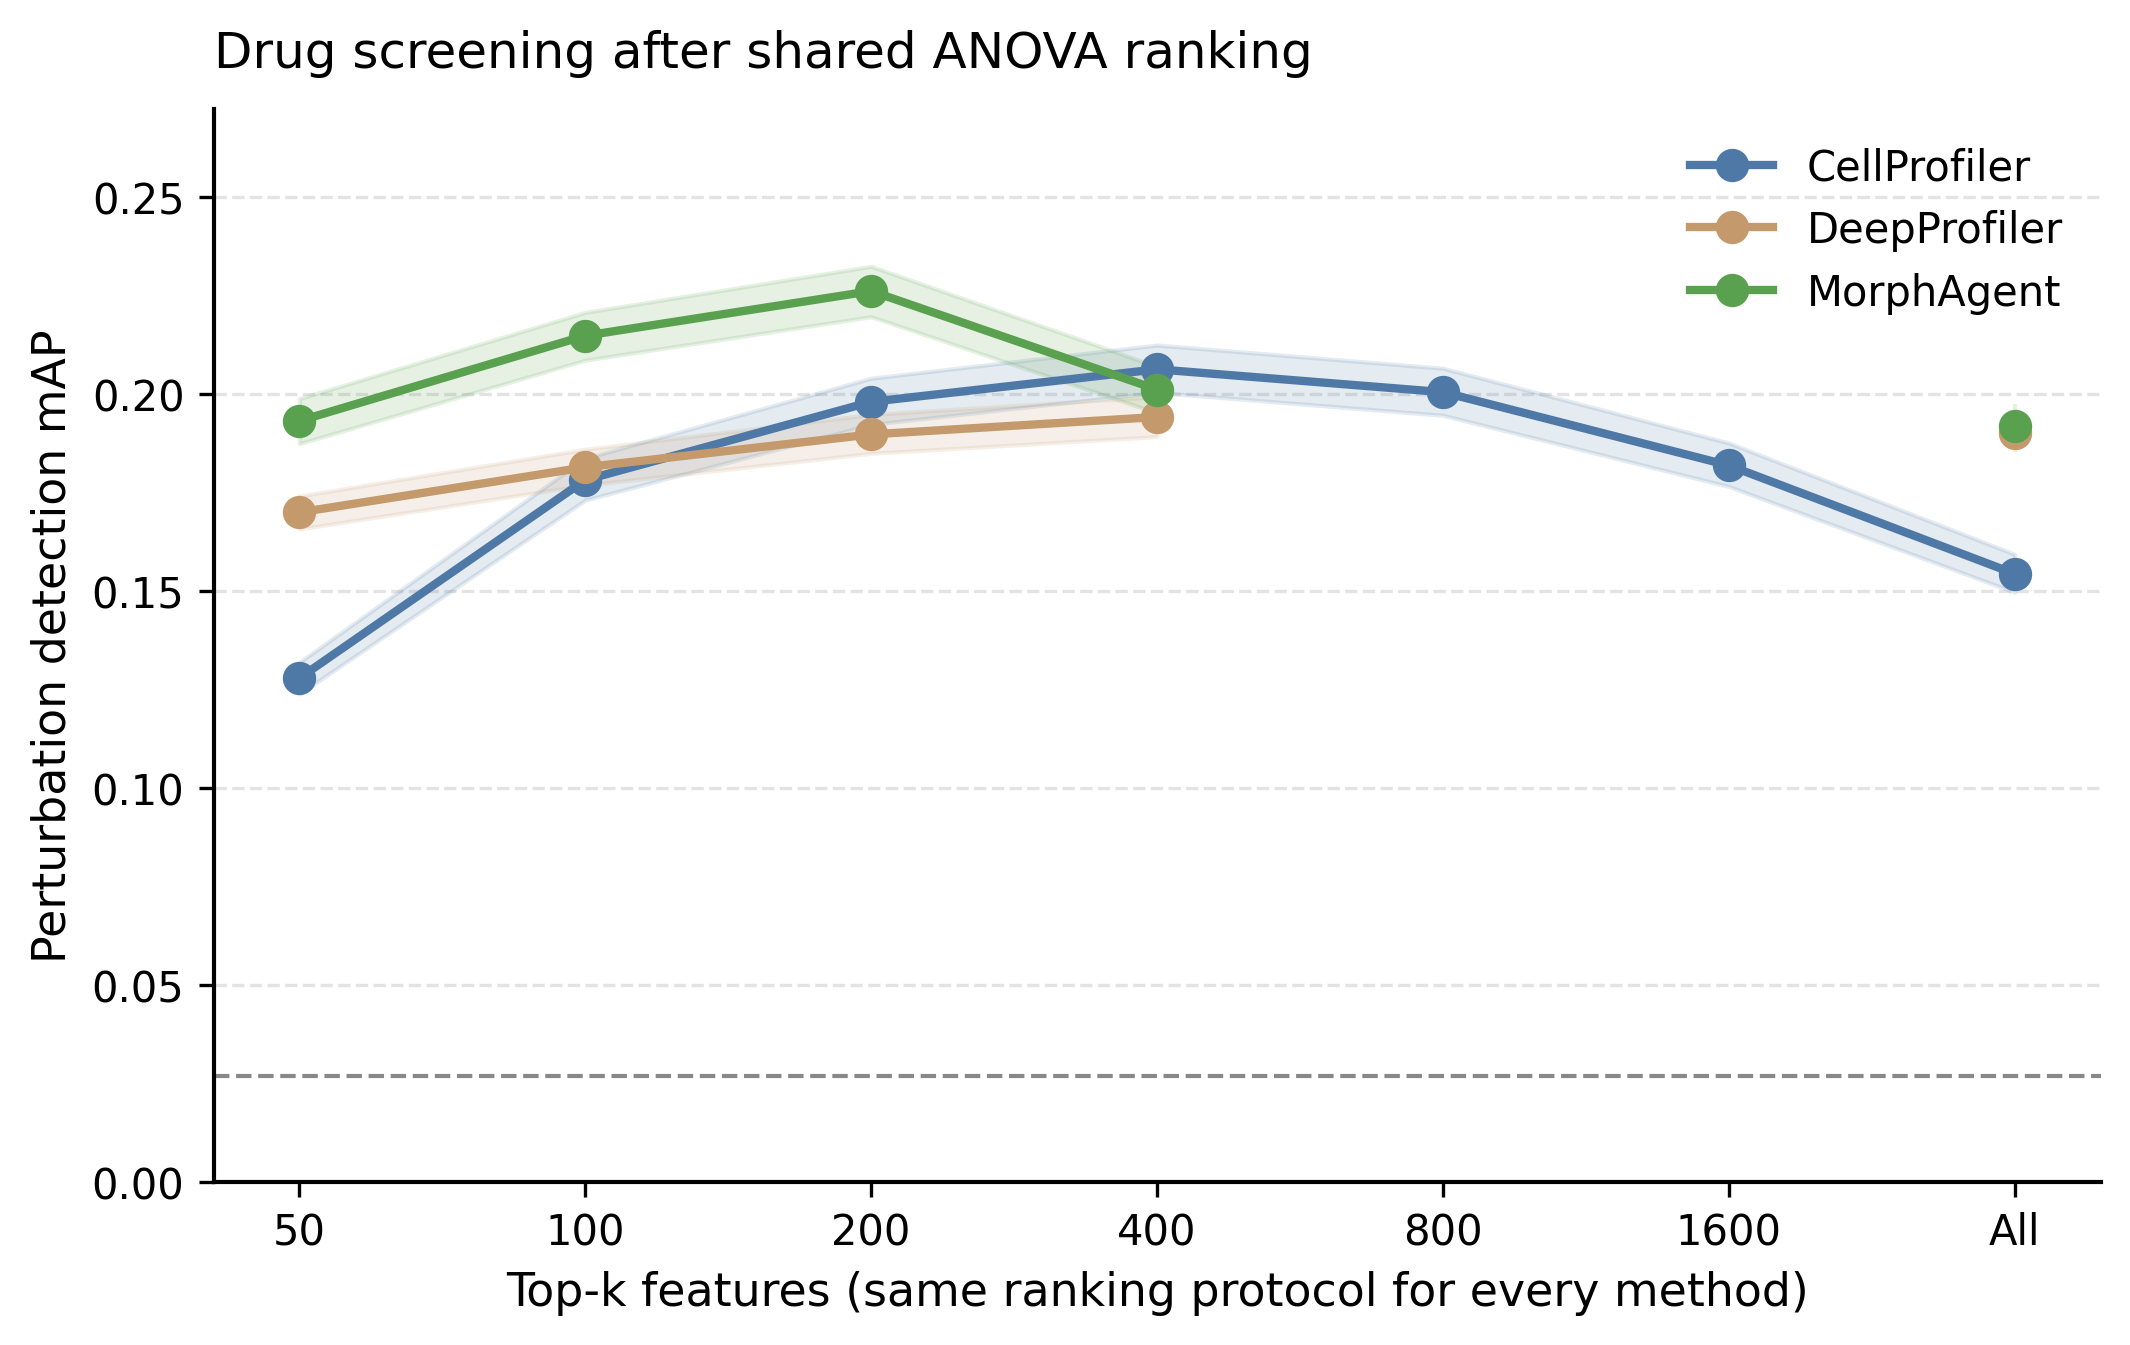


At a matched budget of k=200 ANOVA-ranked features:


,method,n_features,mAP,ci95_low,ci95_high
0,CellProfiler,200,0.198011,0.192255,0.204006
1,DeepProfiler,200,0.189749,0.184947,0.194803
2,MorphAgent,200,0.226113,0.219612,0.232397


MorphAgent remains highest on perturbation detection when every method is ranked the same way.


In [8]:
import importlib
bb = importlib.reload(bb)

si = bb.run_si_anova_perturbation_detection(datasets, recompute=RECOMPUTE)
display(si.pivot(index="k", columns="method", values="mAP"))

png = bb.plot_si_anova_perturbation(si)
display(Image(filename=str(png)))

print("\nAt a matched budget of k=200 ANOVA-ranked features:")
sub = si[si["k"] == "200"][["method", "n_features", "mAP", "ci95_low", "ci95_high"]]
display(sub.reset_index(drop=True))
print(
    "MorphAgent remains highest on perturbation detection "
    "when every method is ranked the same way."
)


## 6. Output files

After a successful run, `outputs/` contains:

- `min_nonredundant_subset.{png,svg,pdf}`
- `four_benchmarks.{png,svg,pdf}`
- `si_anova_perturbation_detection.{png,svg,pdf}`
- `redundancy_min_subset.csv`
- `summary_metrics.csv`
- `si_anova_all_methods.csv`
- `four_benchmark_results_467_4method.json`

CLI equivalent:

```bash
python bbbc021_main_results.py
```
